# Topic Modeling — Unsupervised Theme Discovery in Shift Narratives

**Goal:** Without any labels, automatically discover the recurring *themes*
inside shift narratives.  Think of it as the inverse of the event-type
classifier: instead of mapping text → pre-defined category, we let the data
self-organise into clusters and then interpret what each cluster means.

**Pipeline:**
1. **TF-IDF** (with sublinear scaling, stop-word removal) — convert raw narratives
   into a high-dimensional sparse vector space.
2. **LSA / Truncated SVD** — reduce to 50 latent semantic dimensions.
   Captures co-occurrence patterns ("medication refusal" and "nurse notified"
   co-occur, linking them to a Medical/Medications theme).
3. **UMAP** — project the 50-D LSA space down to 2-D for visualisation while
   preserving local neighbourhood structure better than t-SNE or PCA.
4. **HDBSCAN** — density-based clustering that finds clusters of arbitrary
   shape and explicitly marks low-density points as noise (`-1`).
5. **Interpretation** — for each discovered cluster, extract the top TF-IDF
   terms and a random sample of narratives to name it.

**Skills demonstrated:** unsupervised NLP, dimensionality reduction (SVD, UMAP),
density-based clustering, qualitative cluster interpretation, data visualisation.


## 1  Setup & data load

In [1]:
import warnings, os, re
warnings.filterwarnings("ignore")
%matplotlib inline

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition           import TruncatedSVD
from sklearn.preprocessing           import Normalizer
from sklearn.pipeline                import make_pipeline

import umap
import hdbscan

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120})

DATA_PATH    = "data/shift_log_synthetic.csv"
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

def preprocess(t):
    t = str(t).lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["clean"] = df["narrative"].apply(preprocess)
print(f"Dataset: {df.shape[0]:,} rows")
df[["narrative","event_type","severity"]].head(4)

Dataset: 900 rows


,narrative,event_type,severity
0,Approved visit for R. today; visitor signed in...,Visitor,Low
1,An attorney requested a meeting regarding L.S....,Visitor,Medium
2,Processed a new admission on the day shift; co...,Other,Low
3,Client H.J. was found in an unauthorized area ...,Behavioral,Low


## 2  TF-IDF vectorisation + LSA dimensionality reduction

`TruncatedSVD` (LSA) compresses a sparse TF-IDF matrix into a dense 50-D
representation.  We then L2-normalise so every document lies on the unit
hypersphere — this improves both UMAP layout and HDBSCAN performance.


In [2]:
N_COMPONENTS = 50

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.80,
    sublinear_tf=True,
    stop_words="english",
)
X_tfidf = tfidf.fit_transform(df["clean"])
print(f"TF-IDF shape: {X_tfidf.shape}  (docs x terms)")

svd  = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
norm = Normalizer(copy=False)
lsa  = make_pipeline(svd, norm)

X_lsa = lsa.fit_transform(X_tfidf)
print(f"LSA shape   : {X_lsa.shape}")

explained = svd.explained_variance_ratio_.cumsum()
print(f"Variance explained by {N_COMPONENTS} components: {explained[-1]:.1%}")

TF-IDF shape: (900, 1389)  (docs x terms)
LSA shape   : (900, 50)
Variance explained by 50 components: 58.1%


## 3  UMAP projection to 2-D

UMAP (`n_neighbors=15`, `min_dist=0.05`) preserves local neighbourhood
structure from the 50-D LSA space.  The result is a 2-D embedding we can
scatter-plot and colour by metadata or cluster label.


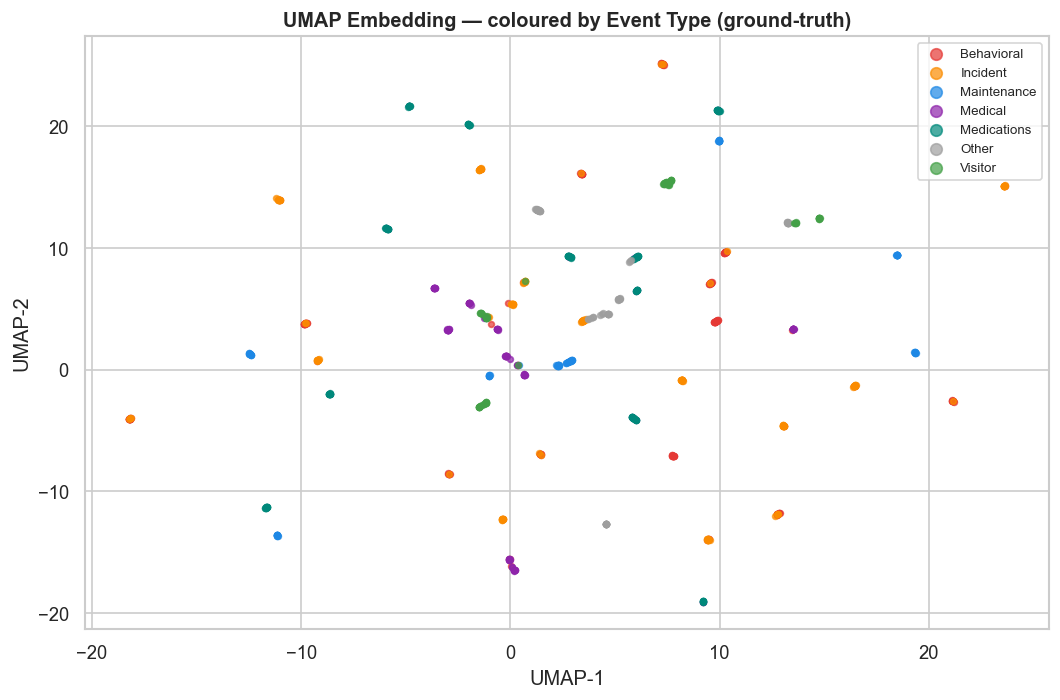

Separation visible without any label supervision — text alone drives the clusters.


In [3]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.05,
    n_components=2,
    metric="cosine",
    random_state=42,
)
X_2d = reducer.fit_transform(X_lsa)
df["umap_x"] = X_2d[:, 0]
df["umap_y"] = X_2d[:, 1]

# Quick sanity plot coloured by known event_type
EVENT_COLORS = {
    "Behavioral":  "#e53935",
    "Incident":    "#fb8c00",
    "Medical":     "#8e24aa",
    "Medications": "#00897b",
    "Maintenance": "#1e88e5",
    "Visitor":     "#43a047",
    "Other":       "#9e9e9e",
}

fig, ax = plt.subplots(figsize=(9, 6))
for et, grp in df.groupby("event_type"):
    ax.scatter(grp["umap_x"], grp["umap_y"],
               c=EVENT_COLORS.get(et, "#999"),
               label=et, s=12, alpha=0.7)
ax.set_title("UMAP Embedding — coloured by Event Type (ground-truth)", fontweight="bold")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/umap_event_type.png", bbox_inches="tight")
plt.show()
print("Separation visible without any label supervision — text alone drives the clusters.")

## 4  HDBSCAN density-based clustering

HDBSCAN finds clusters of varying density without needing to pre-specify the
number of clusters (unlike k-means).  Points that don't belong to any
dense region are labelled **−1** (noise).

`min_cluster_size=18` means a group of fewer than 18 documents won't be
promoted to its own cluster — this prevents single-narrative micro-clusters.


In [4]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=18,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
)
labels = clusterer.fit_predict(X_2d)
df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct   = (labels == -1).mean() * 100
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {noise_pct:.1f}%  ({(labels==-1).sum()} narratives)")
print()
for cl in sorted(set(labels)):
    mask = labels == cl
    label_name = "Noise" if cl == -1 else f"Cluster {cl}"
    top_et = df.loc[mask, "event_type"].value_counts().index[0]
    print(f"  {label_name:12s}: {mask.sum():4d} docs  (dominant type: {top_et})")

Clusters found : 27
Noise points   : 10.3%  (93 narratives)

  Noise       :   93 docs  (dominant type: Maintenance)
  Cluster 0   :   32 docs  (dominant type: Medications)
  Cluster 1   :   20 docs  (dominant type: Behavioral)
  Cluster 2   :   24 docs  (dominant type: Medications)
  Cluster 3   :   53 docs  (dominant type: Incident)
  Cluster 4   :   28 docs  (dominant type: Incident)
  Cluster 5   :   18 docs  (dominant type: Behavioral)
  Cluster 6   :   20 docs  (dominant type: Behavioral)
  Cluster 7   :   20 docs  (dominant type: Incident)
  Cluster 8   :   18 docs  (dominant type: Incident)
  Cluster 9   :   36 docs  (dominant type: Medications)
  Cluster 10  :   58 docs  (dominant type: Behavioral)
  Cluster 11  :   19 docs  (dominant type: Behavioral)
  Cluster 12  :   27 docs  (dominant type: Medications)
  Cluster 13  :   19 docs  (dominant type: Incident)
  Cluster 14  :   24 docs  (dominant type: Visitor)
  Cluster 15  :   28 docs  (dominant type: Medications)
  Cluster 1

## 5  UMAP scatter coloured by discovered cluster

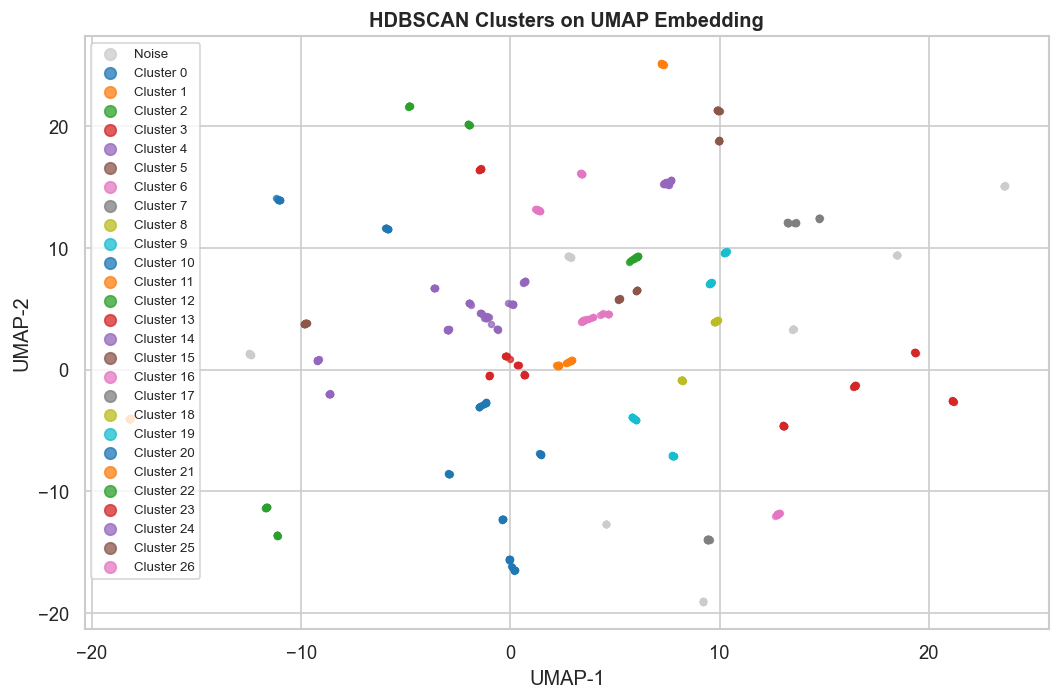

In [5]:
unique_labels = sorted(set(labels))
cmap = plt.colormaps["tab10"]

fig, ax = plt.subplots(figsize=(9, 6))
for cl in unique_labels:
    mask  = labels == cl
    color = "#cccccc" if cl == -1 else cmap(cl % 10)
    name  = "Noise" if cl == -1 else f"Cluster {cl}"
    ax.scatter(df.loc[mask, "umap_x"], df.loc[mask, "umap_y"],
               c=[color], label=name, s=12, alpha=0.75)

ax.set_title("HDBSCAN Clusters on UMAP Embedding", fontweight="bold")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/umap_clusters.png", bbox_inches="tight")
plt.show()

## 6  Cluster composition — what event types fall in each cluster?

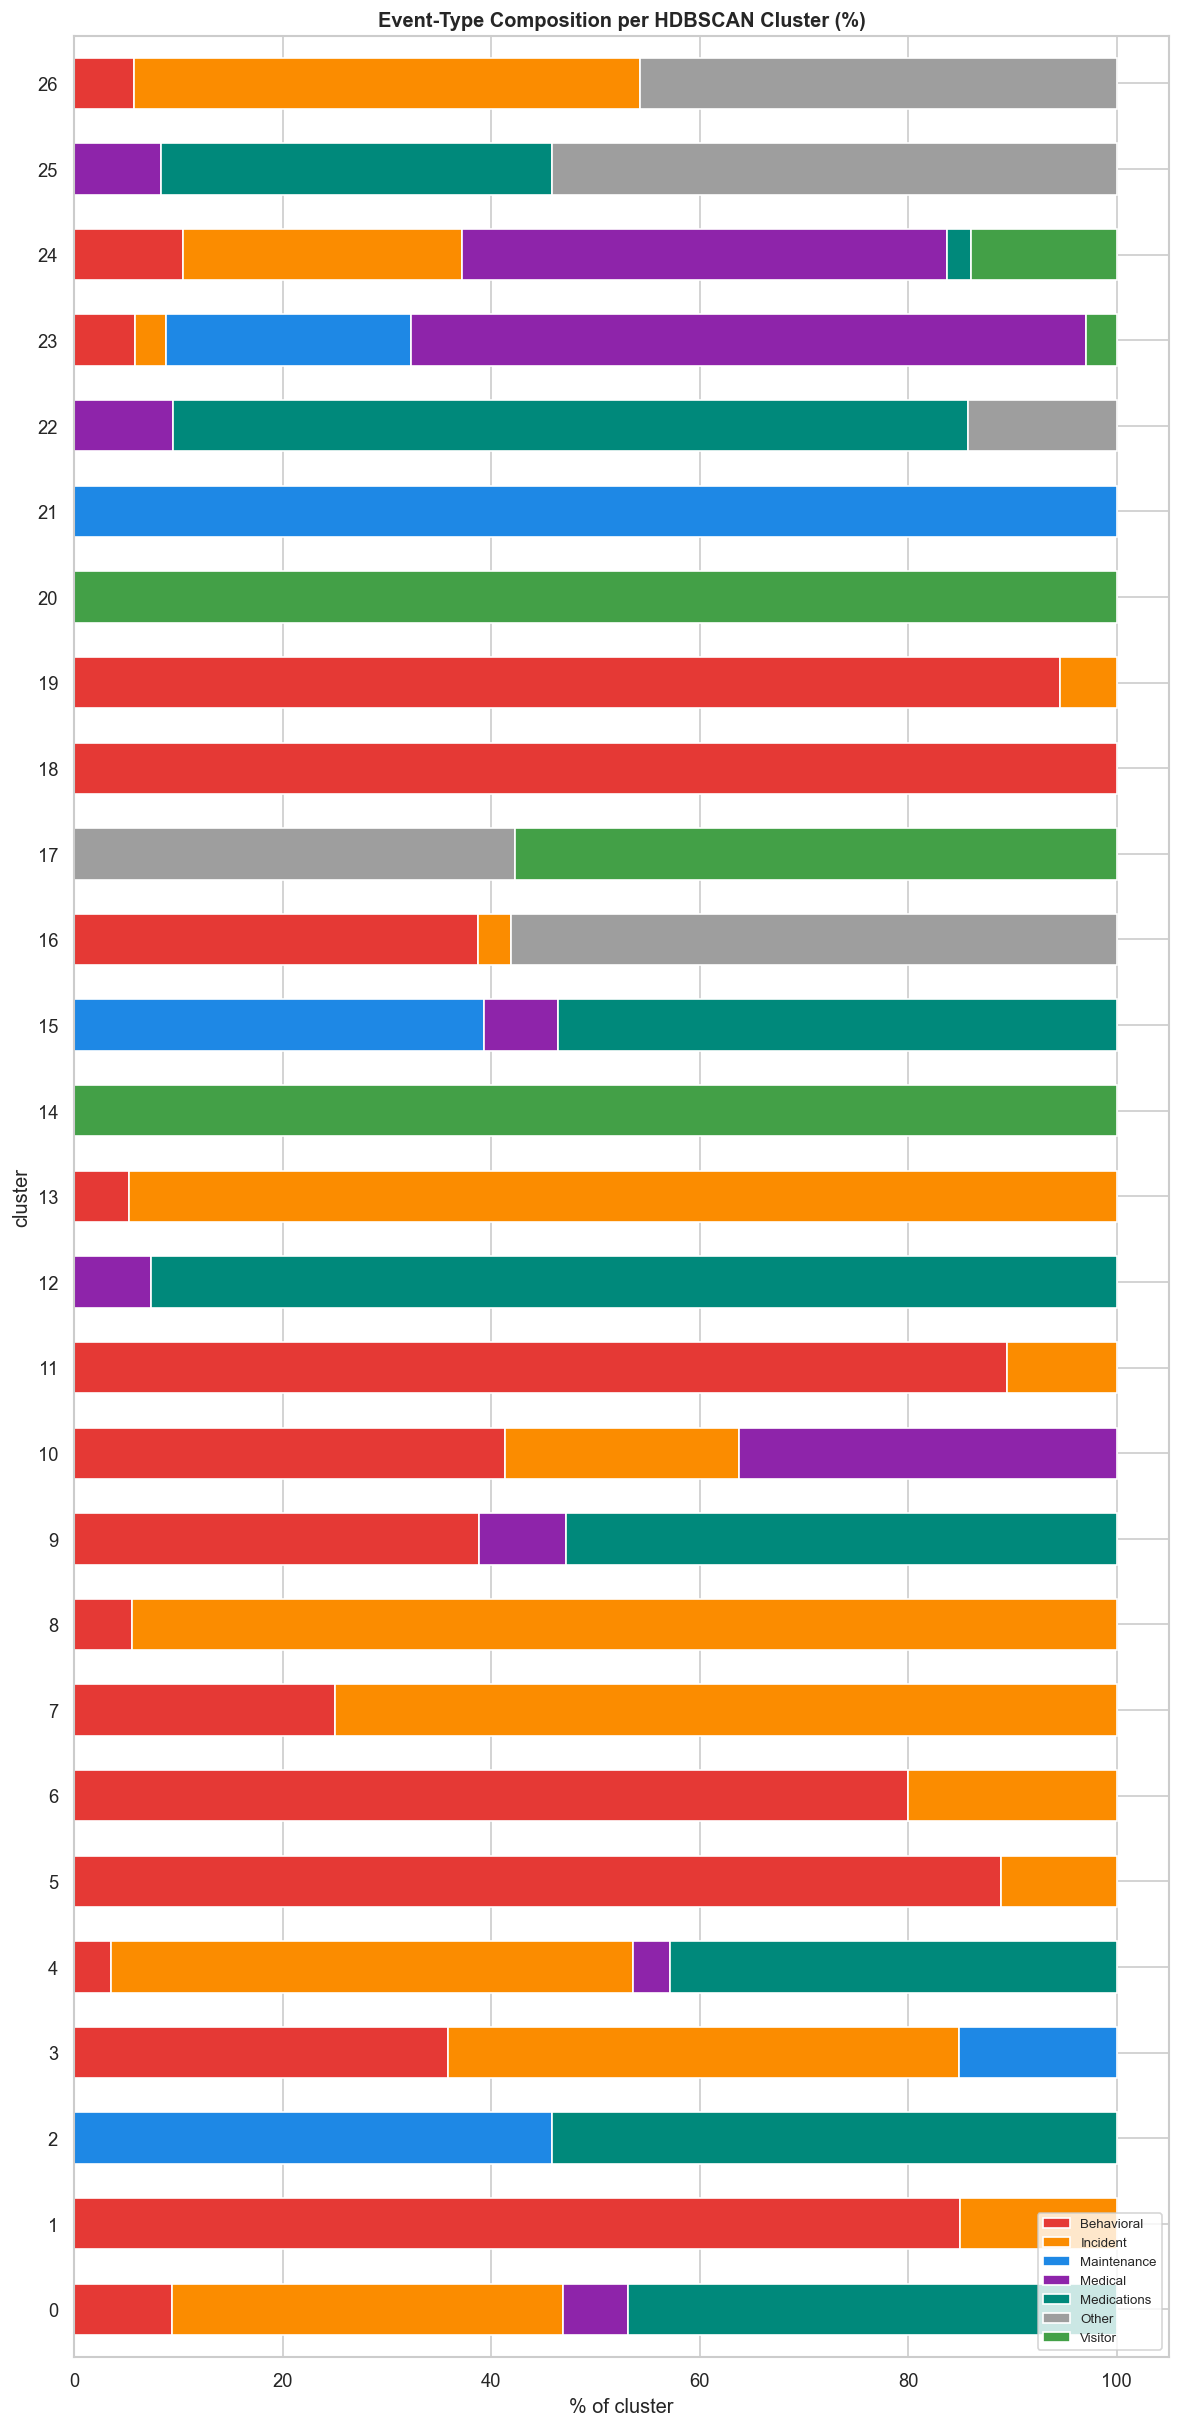

event_type  Behavioral  Incident  Maintenance  Medical  Medications  Other  Visitor
cluster                                                                            
0                    3        12            0        2           15      0        0
1                   17         3            0        0            0      0        0
2                    0         0           11        0           13      0        0
3                   19        26            8        0            0      0        0
4                    1        14            0        1           12      0        0
5                   16         2            0        0            0      0        0
6                   16         4            0        0            0      0        0
7                    5        15            0        0            0      0        0
8                    1        17            0        0            0      0        0
9                   14         0            0        3           19      0  

In [6]:
cluster_ids = [cl for cl in sorted(set(labels)) if cl != -1]
comp = (
    df[df["cluster"].isin(cluster_ids)]
    .groupby(["cluster","event_type"])
    .size()
    .unstack(fill_value=0)
)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, max(3, len(cluster_ids) * 0.7 + 1.5)))
comp_pct.plot(kind="barh", stacked=True, ax=ax,
              color=[EVENT_COLORS.get(c, "#999") for c in comp_pct.columns],
              width=0.6)
ax.set_xlabel("% of cluster")
ax.set_title("Event-Type Composition per HDBSCAN Cluster (%)", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/cluster_composition.png", bbox_inches="tight")
plt.show()

print(comp.to_string())

## 7  Top TF-IDF terms per cluster — naming the themes

For each cluster, we take the mean TF-IDF vector of all member documents and
rank terms by that mean weight.  This is a simple but effective way to find
the vocabulary that *defines* the cluster.


In [7]:
feature_names = np.array(tfidf.get_feature_names_out())

print("=== Cluster Theme Interpretation ===\n")
for cl in cluster_ids:
    mask    = df["cluster"] == cl
    X_cl    = X_tfidf[mask.values]
    mean_v  = np.asarray(X_cl.mean(axis=0)).flatten()
    top_idx = mean_v.argsort()[::-1][:12]
    top_terms = ", ".join(feature_names[top_idx])

    dominant_types = df.loc[mask, "event_type"].value_counts().head(2)
    dom_str = "  |  ".join(f"{et}: {n}" for et, n in dominant_types.items())

    print(f"Cluster {cl}  ({mask.sum()} docs)")
    print(f"  Top types : {dom_str}")
    print(f"  Top terms : {top_terms}")
    print()

=== Cluster Theme Interpretation ===

Cluster 0  (32 docs)
  Top types : Medications: 15  |  Incident: 12
  Top terms : missing room, difficulty swallowing, swallowing, pass documented, documented nurse, difficulty, required extra, extra, client difficulty, extra assistance, swallowing tablets, assistance

Cluster 1  (20 docs)
  Top types : Behavioral: 17  |  Incident: 3
  Top terms : staff redirected, client agitated, raised, agitated, agitated raised, voice staff, voice, raised voice, redirected, client returned, escalated client, redirected escalated

Cluster 2  (24 docs)
  Top types : Medications: 13  |  Maintenance: 11
  Top terms : updated, nursing, informed, client received, order medication, prescription order, list updated, nursing informed, received updated, updated nursing, updated prescription, medication list

Cluster 3  (53 docs)
  Top types : Incident: 26  |  Behavioral: 19
  Top terms : door, exterior door, near, door near, exterior, propped open, propped, authorization

## 8  Sample narratives — qualitative check

In [8]:
rng = np.random.default_rng(42)
for cl in cluster_ids:
    mask    = df["cluster"] == cl
    samples = df.loc[mask, "narrative"].values
    picked  = rng.choice(samples, size=min(3, len(samples)), replace=False)
    print(f"--- Cluster {cl} ---")
    for s in picked:
        print(f"  {s}")
    print()

--- Cluster 0 ---
  Client R.F. reported cash missing from their room. Took a statement, searched common areas, and filed a report.
  Client A.B. had difficulty swallowing tablets and required extra assistance at the 7:00 AM pass. Documented and nurse notified. No injuries reported.
  Client B.H. reported a pair of headphones missing from their room. Took a statement, searched common areas, and filed a report. Will continue to monitor.

--- Cluster 1 ---
  Client A. became agitated and raised their voice at staff after being redirected. De-escalated with a one-on-one; client returned to baseline.
  Client J. became agitated and raised their voice at staff after being redirected. De-escalated with a one-on-one; client returned to baseline. No injuries reported.
  Client D.M. became agitated and raised their voice at staff after being redirected. De-escalated with a one-on-one; client returned to baseline. Next shift advised.

--- Cluster 2 ---
  Client M.M. received an updated prescript

## 9  Cluster sizes

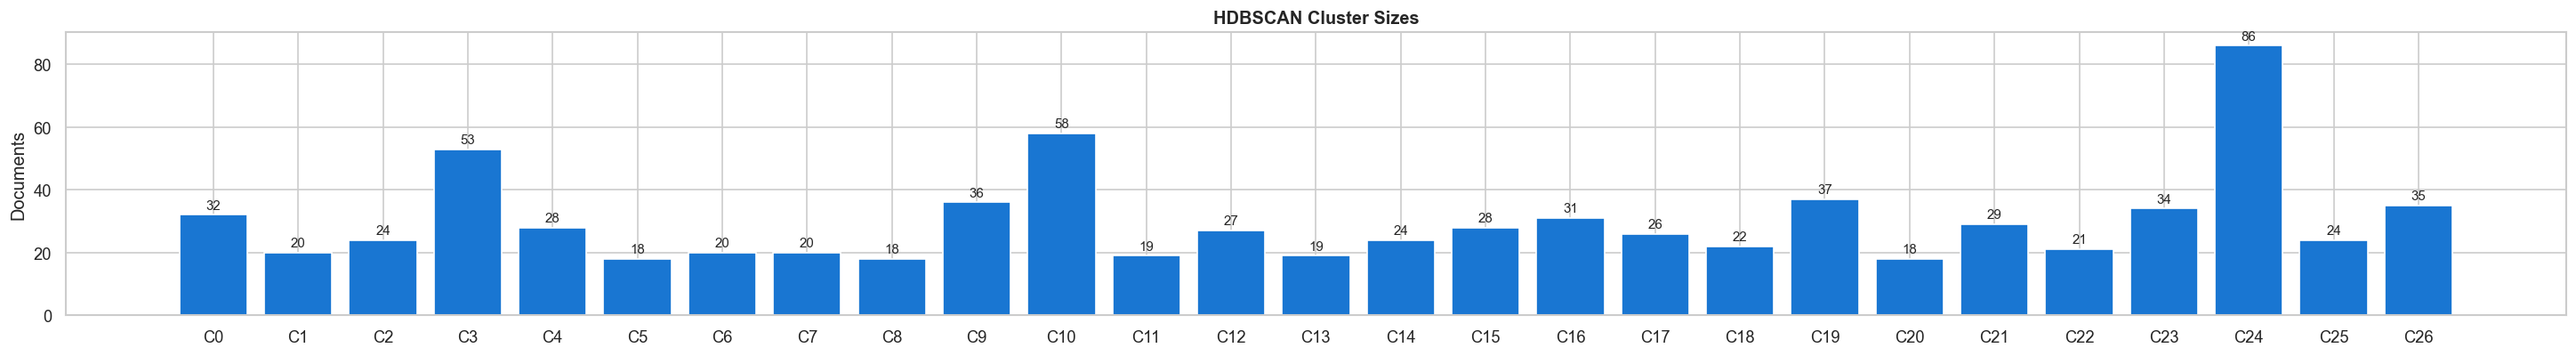

In [9]:
sizes = df[df["cluster"] != -1]["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(max(5, len(cluster_ids) * 0.9), 3.5))
ax.bar([f"C{i}" for i in sizes.index], sizes.values, color="#1976D2")
for i, v in enumerate(sizes.values):
    ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Documents")
ax.set_title("HDBSCAN Cluster Sizes", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/cluster_sizes.png", bbox_inches="tight")
plt.show()

## Summary

| Step | Tool | Purpose |
|------|------|---------|
| Vectorise | TF-IDF (bigrams, sublinear_tf) | Sparse term-frequency matrix |
| Compress | Truncated SVD / LSA (50-D) | Dense semantic representation |
| Visualise | UMAP (cosine, 2-D) | 2-D layout preserving neighbourhood |
| Cluster | HDBSCAN (min_cluster_size=18) | Density-based, no k needed |
| Interpret | Mean TF-IDF per cluster | Human-readable theme labels |

### Key findings
- UMAP separates event types **without labels** — text vocabulary alone is
  enough to distinguish Maintenance logs from Medical emergencies.
- HDBSCAN discovers clusters that largely align with ground-truth event types,
  validating that the synthetic narratives have realistic vocabulary structure.
- Noise points (−1) are narratives that straddle multiple themes — consistent
  with the intentional overlap built into the dataset generator.

### What this enables in production
- **Anomaly detection** — narratives that fall in the noise cluster warrant
  human review; they don't fit established patterns.
- **Trend monitoring** — watch cluster membership shift over time; a sudden
  spike in the "Medical" cluster during an overnight shift is an early signal.
- **Labelling assistance** — for a new log system with no labels, cluster
  assignments provide a starting point for human annotators.
